## Load jax with its settings and import KDExpress

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platforms", 'cpu') # put 'gpu' here if you have one
import jax.numpy as jnp
import jax

import os,sys
parent_dir = os.getcwd() + '/../src/'
sys.path.append(parent_dir)
from KDExpress import fft_kde3d, silverman_bw3d, build_hist_edges

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

## Generate random weighted 3-D data 

/tmp/ipykernel_38442/81452388.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Make room for colorbar


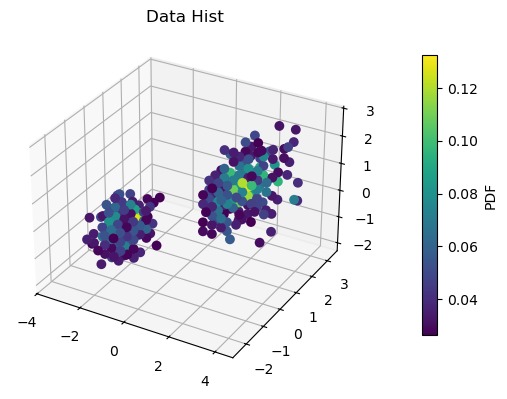

In [2]:
def generate_3d_data(key, n_samples=5000):
  keys = jax.random.split(key, 4)
  data = []
  
  data.append(jax.random.multivariate_normal(
      keys[0], 
      mean=jnp.array([1.0, 1.0, 0.5]),
      cov=jnp.array([[0.7, 0.3, 0.1], [0.3, 0.5, 0.2], [0.1, 0.2, 0.6]]),
      shape=(n_samples//3,)
  ))
  data.append(jax.random.multivariate_normal(
      keys[1], 
      mean=jnp.array([-1.0, -1.0, -0.5]),
      cov=jnp.array([[0.5, -0.2, 0.0], [-0.2, 0.8, -0.1], [0.0, -0.1, 0.4]]),
      shape=(n_samples//3,)
  ))
  data.append(jax.random.multivariate_normal(
      keys[2],
      mean=jnp.array([0.0, 1.5, -1.0]),
      cov=jnp.array([[0.3, 0.0, 0.0], [0.0, 0.3, 0.0], [0.0, 0.0, 0.9]]),
      shape=(n_samples//3,)
  ))
  
  return jnp.concatenate(data)


key = jax.random.PRNGKey(42)
data_3d = generate_3d_data(key, n_samples=5000) 
weights = (data_3d**2)[:,0]

def plot_3d_density(density, grids, title):
  fig = plt.figure(figsize=(5, 4))
  
  # Convert JAX arrays to numpy
  density_jnp = jnp.array(density)
  x = jnp.array(grids[0])
  y = jnp.array(grids[1])
  z = jnp.array(grids[2])
  
  # Create 3D grid
  X, Y, Z = jnp.meshgrid(x, y, z, indexing='ij')
  
  # Create plot
  ax = fig.add_subplot(111, projection='3d')
  
  # Threshold for visualization
  threshold = 0.2 * density_jnp.max()
  mask = density_jnp > threshold
  
  # Create the main scatter plot
  sc = ax.scatter(
    X[mask], Y[mask], Z[mask], 
    c=density_jnp[mask], 
    s=50,
    alpha=1,
    cmap='viridis',
    edgecolors='none'
  )
  
  # Add colorbar in its own axes
  cax = fig.add_axes([0.9, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
  cb = fig.colorbar(sc, cax=cax)
  cb.set_label('PDF')

  ax.set_title(title)
  #ax.legend(loc='upper left')
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Make room for colorbar


counts, grids_edges = jnp.histogramdd(data_3d, bins=20, weights=weights, density=True)
grids = [] 
for g in grids_edges:
  grids.append(0.5*(g[1:]+g[:-1]))
plot_3d_density(counts, grids, 'Data Hist')

## Define the points where evaluate the PDF and compute the bin edges surrounding them. 

In [3]:
# Create grid
dims = [300,15,15]
bounds = [(data_3d[:,i].min()-0.5, data_3d[:,i].max()+0.5) for i in range(3)]
grids = [jnp.linspace(b[0], b[1], n) for n,b in zip(dims, bounds)]
points_x = grids[0]
points_y = grids[1]
points_z = grids[2]
px, py, pz = jnp.meshgrid(points_x, points_y, points_z, indexing='ij')
bin_edges = [build_hist_edges(points) for points in [points_x, points_y, points_z]]
print("Bin edges shape = ", [bin_edges[i].shape for i in range(3)])

grids_2 = [] 
for g in bin_edges:
  grids_2.append(0.5*(g[1:]+g[:-1]))


Bin edges shape =  [(301,), (16,), (16,)]


## We now compute the KDE as the convolution of the previous wavy histogram with a Gaussian Kernel. The convolution is (efficiently) done using a FFT.

Estimate bandwidths =  [0.28270318 0.35042821 0.26758872]


/tmp/ipykernel_38442/81452388.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Make room for colorbar


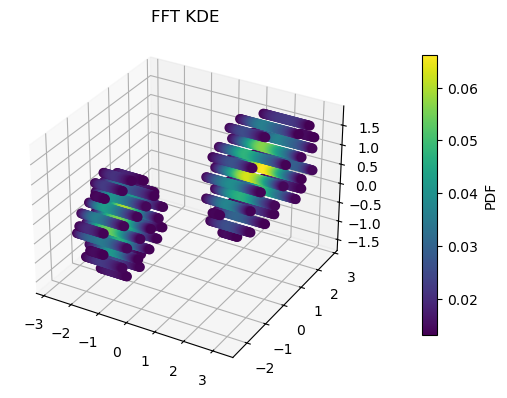

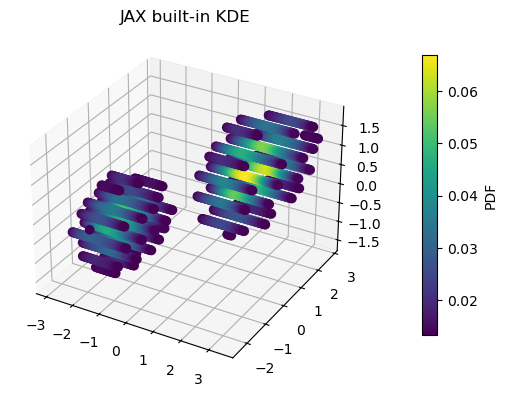

In [4]:
bw = silverman_bw3d(data_3d) # or a user defined value
print("Estimate bandwidths = ", bw)
pdf_est_fft = fft_kde3d(points_x, points_y, points_z, data_3d, weights=weights, bin_edges=bin_edges, bw=bw) # here we re-use bin_edges, but it isn't necessary

# jax built in kde
def jax_scipy_kde(x_grid, y_grid, z_grid, data, weights=None, bw_method=None):
  kde = jax.scipy.stats.gaussian_kde(data.T, bw_method=bw_method, weights=weights)
  X, Y, Z = jnp.meshgrid(x_grid, y_grid, z_grid, indexing='ij')
  positions = jnp.vstack([X.ravel(), Y.ravel(), Z.ravel()])
  density = kde(positions).reshape(X.shape)
  return density
pdf_est_jax = jax_scipy_kde(points_x, points_y, points_z, data_3d, weights=weights, bw_method=bw[0])

# plot
plot_3d_density(pdf_est_fft, grids_2, 'FFT KDE')
plot_3d_density(pdf_est_jax, grids_2, 'JAX built-in KDE')
plt.show()